#### <strong>第一次作品：主成分分析實作</strong>
作業編號：1

學號：711133108

姓名：林楷博
<hr>

 <font color=skyblue>作品目標</font>：在上學期學習了多變量分析課程，學習了PCA的理念，並且也以python實做過，本次作業再次複習此概念，並且將之前較不懂的地方重新理解，同時也複習過去線性代數所學的概念。

習題(一)紅酒資料集實證:
資料來自義大利某個地區三個紅酒製造商所產的紅酒，資料內容包括的 178 支紅酒的 13 種化學成分。利用這組資料回答下列問題：

In [1]:
# 本次使用的套件
import pandas as pd
import numpy as np
import seaborn
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from numpy.linalg import eig
from matplotlib.ticker import PercentFormatter
from sklearn.decomposition import PCA
import plotly.express as px
import seaborn as sns

**<font color=skyblue>第 1 題：</font>**
- Claim:觀察變數間是否存在相關性
    - 繪製變數間的相關係數圖了解變數間的相關性。
    - 相關係數矩陣為對稱矩陣，因此僅呈現下半部熱點圖

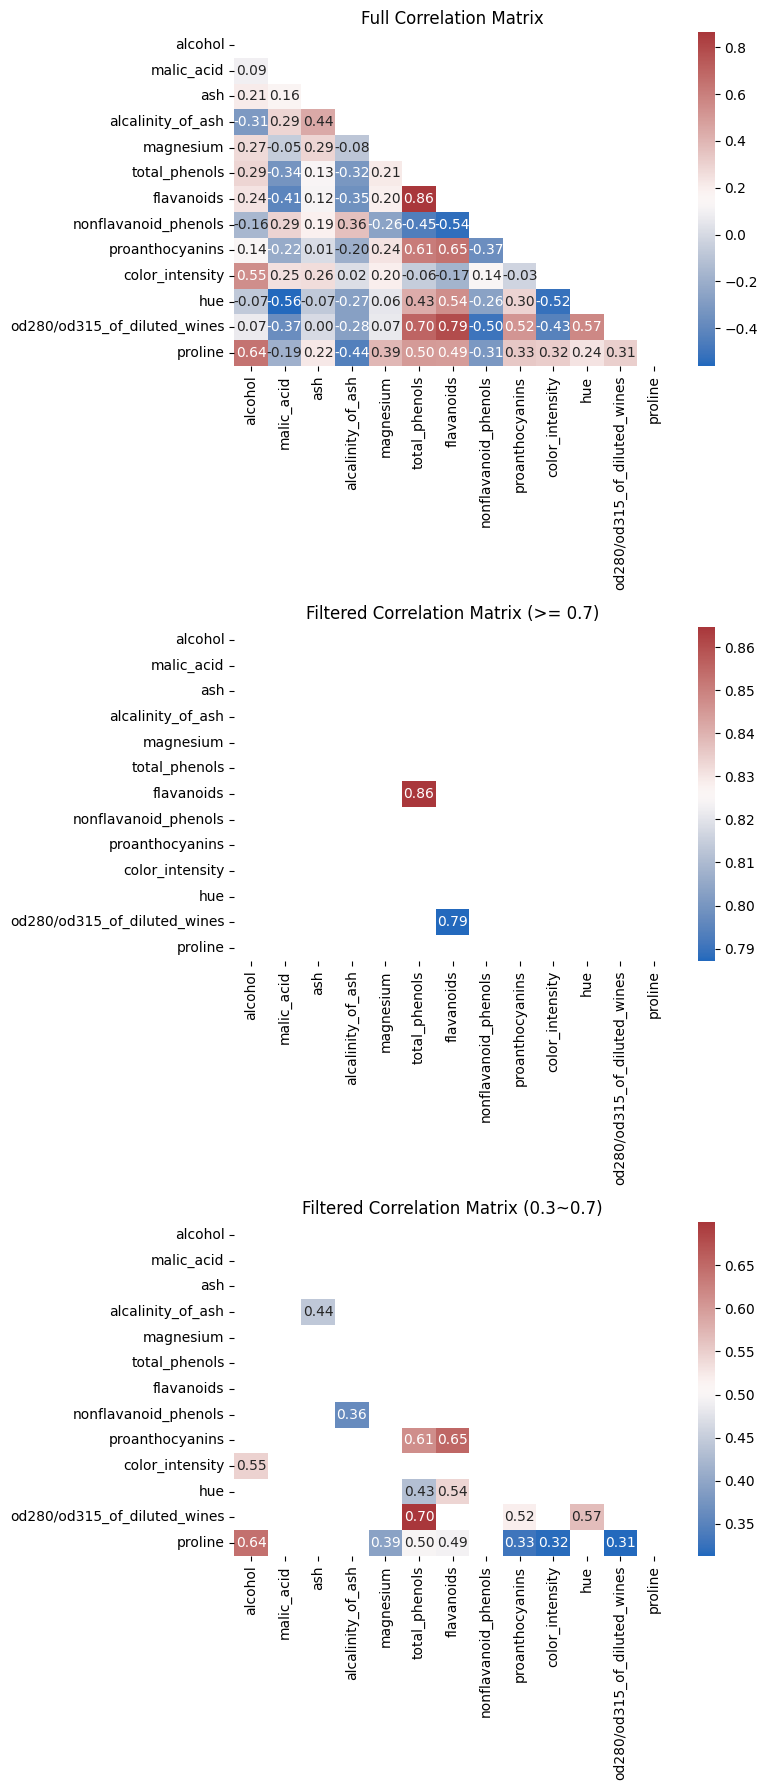

In [2]:
# Load the wine dataset
X, y = load_wine(return_X_y=True, as_frame=True)
labels = X.columns

# Plot the correlation matrix with two decimal places
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

# Full correlation matrix
R = X.corr()
mask = np.triu(np.ones_like(R, dtype=bool))  # diagonal mask
seaborn.heatmap(R, annot=True, mask=mask, cmap='vlag', fmt=".2f", ax=axes[0])  # Use fmt=".2f" for two decimal places
axes[0].set_title('Full Correlation Matrix')

# Filtered correlation matrix
R_filtered = R[(R >= 0.7) & (R < 1)]  # Filter correlation matrix for values greater than or equal to 0.7
mask_filtered = np.triu(np.ones_like(R_filtered, dtype=bool))
seaborn.heatmap(R_filtered, annot=True, mask=mask_filtered, cmap='vlag', fmt=".2f", ax=axes[1])  # Use fmt=".2f" for two decimal places
axes[1].set_title('Filtered Correlation Matrix (>= 0.7)')

# Filtered correlation matrix
R_filtered_mid = R[(R >= 0.3) & (R < 0.7)]  
mask_filtered_mid = np.triu(np.ones_like(R_filtered_mid, dtype=bool))
seaborn.heatmap(R_filtered_mid, annot=True, mask=mask_filtered_mid, cmap='vlag', fmt=".2f", ax=axes[2])  # Use fmt=".2f" for two decimal places
axes[2].set_title('Filtered Correlation Matrix (0.3~0.7)')
plt.tight_layout()
plt.show()


**<font color=skyblue>結果的觀察與討論：</font>**
- 第一張圖呈現所有變數之間的相關係數，並控制四捨五入至小數點第二位
- 第二張圖呈現高度相關的變數
    - 變數flavanoids與變數total_phenols相關係數達0.86
    - 變數flavanoids與變數od280/od315_of_diluted_wines相關係數達0.79
- 第三張圖呈現中度相關的變數
    - 其中以變數total_phenols與變數od280/od315_of_diluted_wines最高近似到0.7
- 如需做資料縮減，建議從此三變數進行合併新變數或者刪除其中某個變數下手
    

**<font color=skyblue>第 2 題：</font>**
- Claim:了解變數是否需要標準化
    - 繪製一張含每個化學成分（變數）的盒鬚圖（Boxplot），觀察每個變數的 scaling，作為是否標準化的參考。

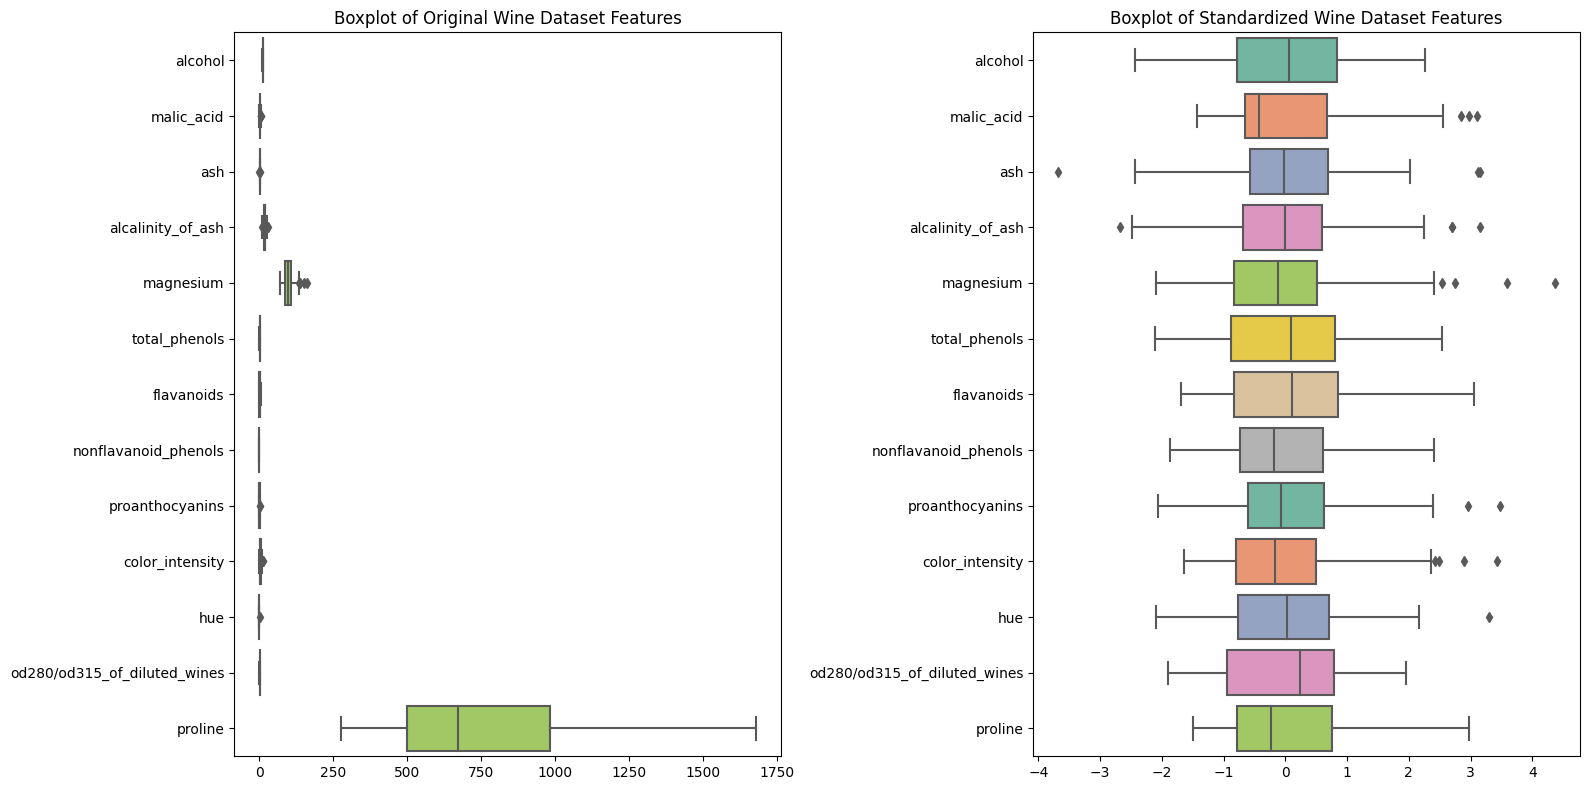

In [3]:
# Create boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot original data
seaborn.boxplot(data=X, orient="h", palette="Set2", ax=axes[0])
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels)
axes[0].set_title('Boxplot of Original Wine Dataset Features')

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plot standardized data
seaborn.boxplot(data=X_scaled, orient="h", palette="Set2", ax=axes[1])
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels)
axes[1].set_title('Boxplot of Standardized Wine Dataset Features')

plt.tight_layout()
plt.show()

**<font color=skyblue>結果的觀察與討論：</font>**
- 左圖呈現未經標準化的盒鬚圖
    - 可以看出proline變數明顯與其他變數有很大的單位差異
- 右圖呈現經標準化的盒鬚圖
- 建議使用標準化變數，避免後續模型因變數的單位不同，而造成模型權重偏向數值較大的變數，或者模型係數大小差異極大的問題。
    

**<font color=skyblue>第 3 題：</font>**
- Claim:進行主成分分析，繪製特徵值由大而小的分布與 scree plot。
    - 繪製未標準化與標準化後變數的Scree plot與Pareto plot

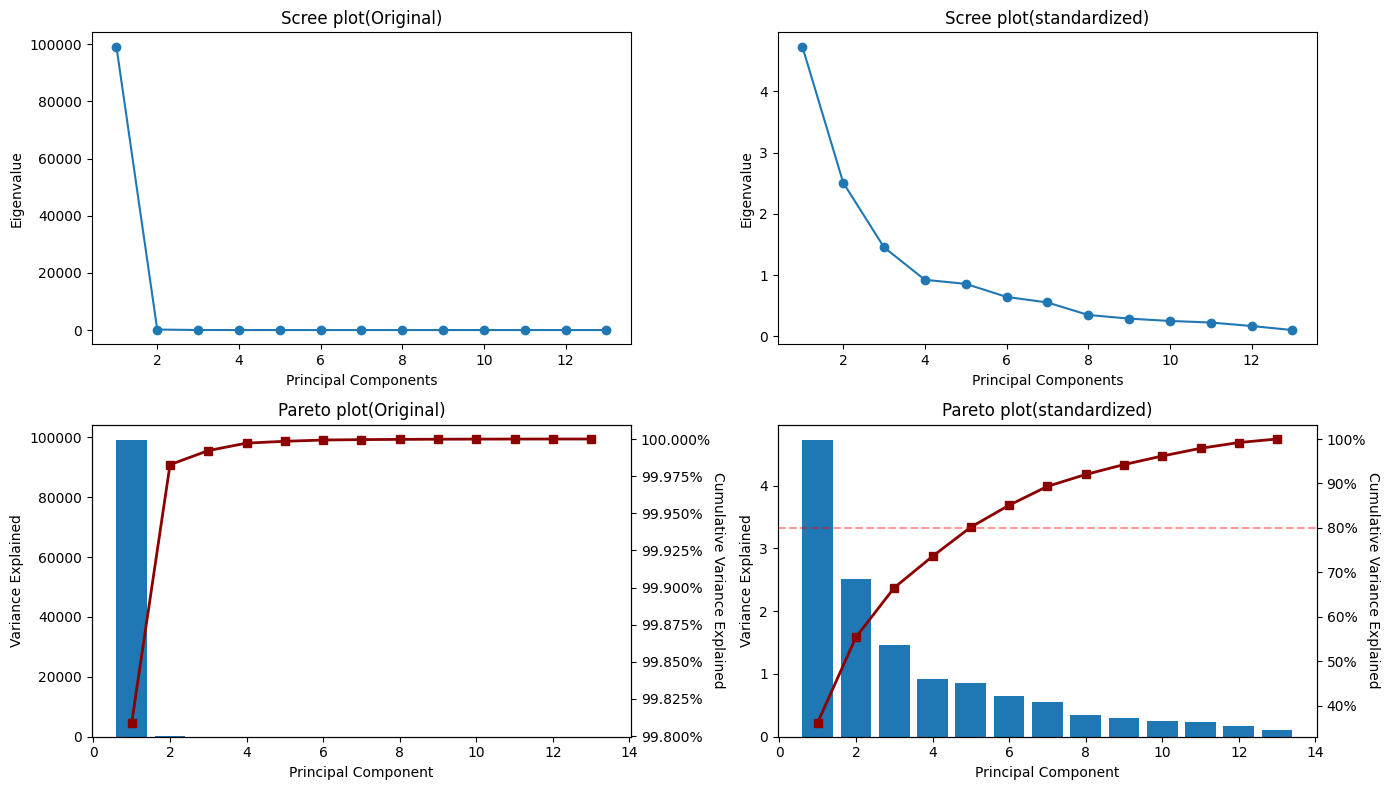

In [4]:
# Calculate covariance matrix and perform eigen decomposition
Sx = np.cov(X.T, bias=False)
w, v = eig(Sx)
idx = np.argsort(w)[::-1]
eigvals = w[idx]
eigvecs = v[:, idx]
Sigma_x = eigvecs @ np.diag(eigvals) @ eigvecs.T

# Plot original data scree plot and Pareto plot
plt.figure(figsize=(14, 8))
plt.subplot(221)
x = np.arange(1, 1 + len(eigvals))
plt.plot(x, eigvals, marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.title('Scree plot(Original)')

plt.subplot(223)
ax = plt.gca()
ax.bar(x, eigvals)
ax2 = ax.twinx()
ax2.plot(x, eigvals.cumsum() / eigvals.sum() * 100, marker='s', color='darkred', lw=2)
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax2.set_ylabel('Cumulative Variance Explained', rotation=270, labelpad=10)
plt.title('Pareto plot(Original)')

# Calculate covariance matrix and perform eigen decomposition for standardized data
Sx2 = np.cov(X_scaled.T, bias=False)
w2, v2 = eig(Sx2)
idx2 = np.argsort(w2)[::-1]
eigvals2 = w2[idx2]
eigvecs2 = v2[:, idx2]
Sigma_x2 = eigvecs2 @ np.diag(eigvals2) @ eigvecs2.T

# Plot standardized data scree plot and Pareto plot
plt.subplot(222)
x2 = np.arange(1, 1 + len(eigvals2))
plt.plot(x2, eigvals2, marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.title('Scree plot(standardized)')

plt.subplot(224)
ax = plt.gca()
ax.bar(x2, eigvals2)
ax2 = ax.twinx()
ax2.plot(x2, eigvals2.cumsum() / eigvals2.sum() * 100, marker='s', color='darkred', lw=2)
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax2.set_ylabel('Cumulative Variance Explained', rotation=270, labelpad=10)
plt.title('Pareto plot(standardized)')
plt.axhline(y=80, color='r', linestyle='--', alpha = 0.4)  # Draw horizontal line at y=4
plt.tight_layout()
plt.show()

**<font color=skyblue>結果的觀察與討論：</font>**
- 左方為未標準化的Scree plot與Pareto plot
    - 可以看出第一個特徵值極大，應該是因為proline變數明顯與其他變數有很大的單位差異所導致
    - 如果採用此結果，因Scree plot結構轉變點在第2個主成分，我會使用兩個變數進行後續研究。
- 右方為標準化的Scree plot與Pareto plot
    - 可以看出特徵值最大不超過4，所有的特徵值數值差異沒未標準化數據的大
    - 如果採用此結果，Scree plot並沒有發生明顯的結構轉變點，因此我會以Pareto plot在第五個變數解釋近80%的樣本的觀察，後續研究使用五個變數。
- 建議使用標準化變數的結果進行後續分析。
    

**<font color=skyblue>第 4 題：</font>**
- Claim:利用主成分分析取得前兩項成分，並繪製其散布圖。是否可以從散布圖中看出三個群組？
    - 繪製未標準化數據與標準化數據的散布圖

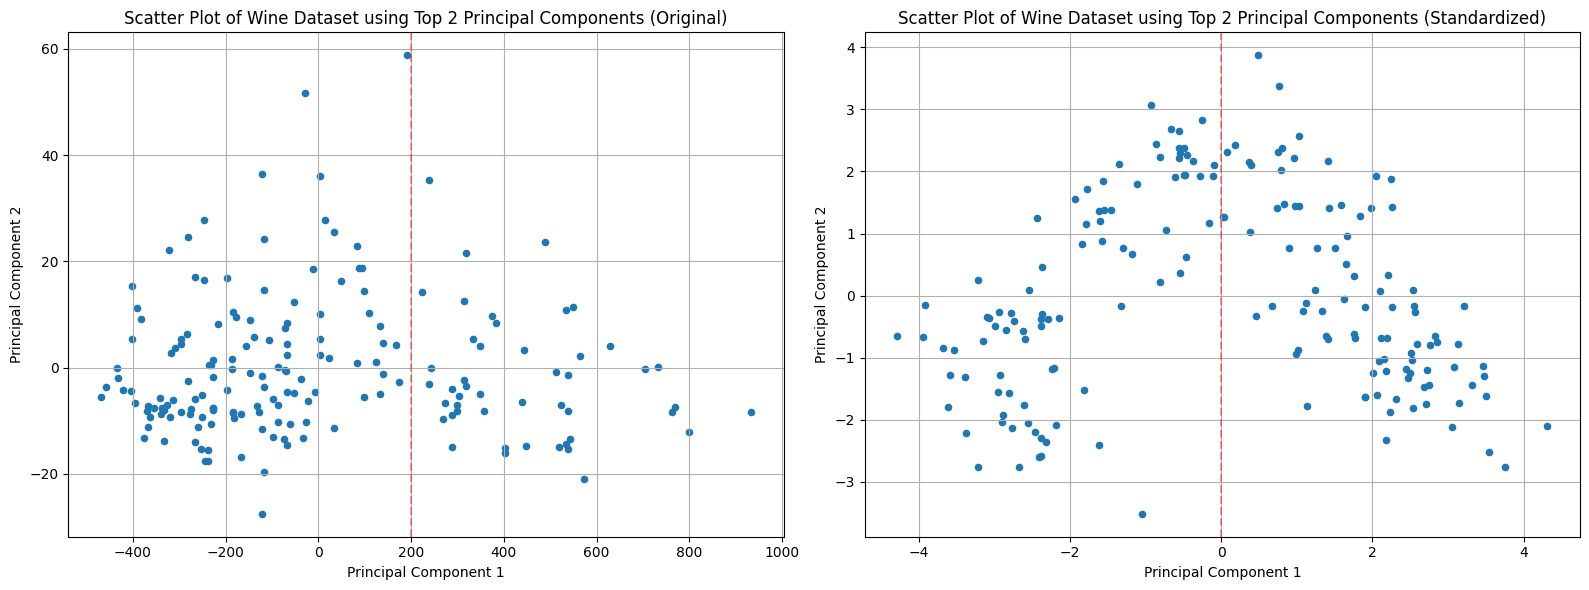

In [5]:
# Fit PCA and transform the data to the new space
PCA_result = PCA(n_components=2).fit_transform(X)

# Plot the scatter plot
plt.figure(figsize=(16, 6))

# Plot for the original data
plt.subplot(1, 2, 1)
plt.scatter(PCA_result[:, 0], PCA_result[:, 1], s=20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of Wine Dataset using Top 2 Principal Components (Original)')
plt.axvline(x=200, color='r', linestyle='--', alpha = 0.4)  # Draw vertical line at x=0
plt.grid(True)

# Fit PCA and transform the standardized data to the new space
PCA_result2 = PCA(n_components=2).fit_transform(X_scaled)

# Plot for the standardized data
plt.subplot(1, 2, 2)
plt.scatter(PCA_result2[:, 0], PCA_result2[:, 1], s=20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of Wine Dataset using Top 2 Principal Components (Standardized)')
plt.grid(True)
plt.axvline(x=0, color='r', linestyle='--', alpha = 0.4)  # Draw vertical line at x=0
plt.tight_layout()
plt.show()

**<font color=skyblue>結果的觀察與討論：</font>**
- 左方為未標準化的散布圖(紅線部分為猜測的群組的分界部分)
- 右方為標準化的散布圖(紅線部分為猜測的群組的分界部分)
- 如果使用兩個主成分的散佈圖觀察僅能分辨出大致兩種群組的分布情況，猜測因變數不足以有效分辨出其中一種群組與其他群組的差異

**<font color=skyblue>第 5 題：</font>**
- Claim:呈上題，為散佈圖標示上群組的分別
    - 繪製未標準化數據與標準化數據的散布圖，並塗上群組顏色

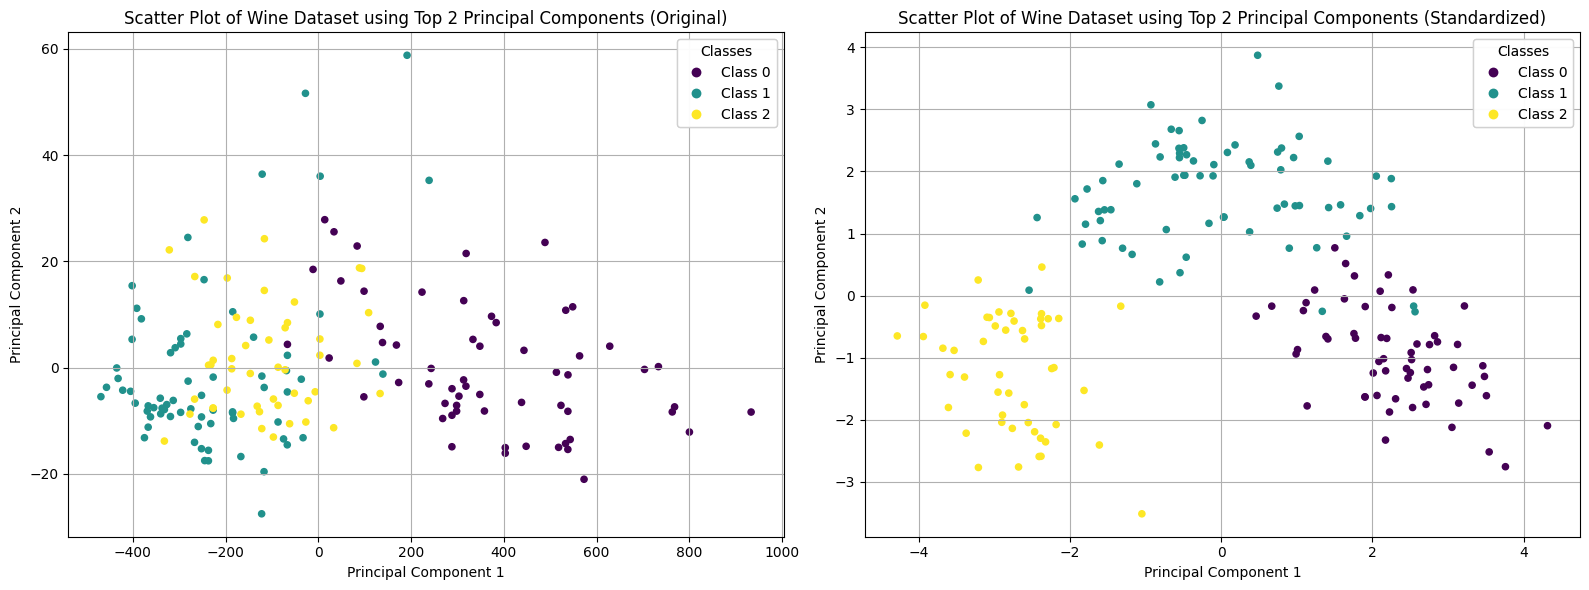

In [6]:
# Fit PCA and transform the data to the new space
PCA_result = PCA(n_components=2).fit_transform(X)

# Plot the scatter plot
plt.figure(figsize=(16, 6))

# Plot for the original data
plt.subplot(1, 2, 1)
scatter = plt.scatter(PCA_result[:, 0], PCA_result[:, 1], s=20, c=y, label='Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of Wine Dataset using Top 2 Principal Components (Original)')
plt.grid(True)
legend1 = plt.legend(handles=scatter.legend_elements()[0], labels=['Class 0', 'Class 1', 'Class 2'], title="Classes", loc='upper right')
plt.gca().add_artist(legend1)

# Fit PCA and transform the standardized data to the new space
PCA_result2 = PCA(n_components=2).fit_transform(X_scaled)

# Plot for the standardized data
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(PCA_result2[:, 0], PCA_result2[:, 1], s=20, c=y, label='Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of Wine Dataset using Top 2 Principal Components (Standardized)')
plt.grid(True)
legend2 = plt.legend(handles=scatter2.legend_elements()[0], labels=['Class 0', 'Class 1', 'Class 2'], title="Classes", loc='upper right')
plt.gca().add_artist(legend2)

plt.tight_layout()
plt.show()

**<font color=skyblue>結果的觀察與討論：</font>**
- 左方為未標準化的散布圖
    -僅能看出紫色與其餘群組的分區
- 右方為標準化的散布圖
    -可以發現三個群組明顯被分為三區
- 在兩個主成分的情況下，標準化數據在此樣本中比未標準化數據，更有效地分辨出三個群組的差別。
- 相比於原本的13個變數，使用PCA的方法可以有效把變數數量降低，並很好地分出三個群組。

**<font color=skyblue>第 6 題：</font>**
- Claim:利用主成分分析取得前三項成分，並繪製其散布圖。是否可以從散布圖中看出三個群組？
    - 繪製未標準化數據與標準化數據的散布圖

In [7]:
# Fit PCA and transform the data to the new space
PCA_result = PCA(n_components=3).fit_transform(X)

# Create a DataFrame for Plotly Express
df = pd.DataFrame(PCA_result, columns=['PC1', 'PC2', 'PC3'])
df['Class'] = y

# Create an interactive 3D scatter plot using Plotly Express
fig = px.scatter_3d(df, x='PC1', y='PC2', z='PC3', color='Class', title='3D Scatter Plot of Original Wine Dataset using Top 3 Principal Components',
                    size_max=5)
fig.update_traces(marker_size = 4)
fig.show()
# Fit PCA and transform the data to the new space
PCA_result2 = PCA(n_components=3).fit_transform(X_scaled)

# Create a DataFrame for Plotly Express
df2 = pd.DataFrame(PCA_result2, columns=['PC1', 'PC2', 'PC3'])
df2['Class'] = y

# Create an interactive 3D scatter plot using Plotly Express
fig = px.scatter_3d(df2, x='PC1', y='PC2', z='PC3', color='Class', title='3D Scatter Plot of standardize Wine Dataset using Top 3 Principal Components',
                    size_max=5)
fig.update_traces(marker_size = 4)
fig.show()

**<font color=skyblue>結果的觀察與討論：</font>**
- 上方為未標準化的立體散布圖
    -從不同角度看均會發現群組1與群組2混雜在一起，無法有效分別出兩種群組
- 下方為標準化的立體散布圖
    -經過嘗試後發現最能有效分別三個群組的角度為從正上方往下看，即只看PC1與PC2的平面
- 經過立體散布圖會發現
    - 使用未標準化的資料，三個主成分也未能有效分辨出群組的界線
    - 使用標準化的資料，兩個主成分即可有效分辨出群組的界線
    - 因此選擇主成分方法的話，使用標準化的資料及兩個主成分會是這個數據集的最佳解

**<font color=skyblue>第 7 題：</font>**
- Claim:了解新變數$Z_1$與$Z_2$的組成方式
    - 對於對稱矩陣$A$來說(因A矩陣為相關係數矩陣，必為對稱矩陣)，必可寫為光譜分解式$A=\lambda_1v_1v_1^*+\cdots+\lambda_mv_mv_m^*$，其中$v_i$為第$i$個特徵值的特徵向量，$\lambda_i$從大排到小，$i=1,2,...,13$
    - 因為$Z_1$=$\lambda_1v_1v_1^*$，所以影響$Z_1$值最多的即為$v_1$中最大值的變數，$Z_2$也同理

In [8]:
pca = PCA(n_components=2).fit(X)
eigvecs = pca.components_.T

# Get the indices of the top three highest coefficients for PC1
top_three_indices_pc1 = np.argsort(abs(eigvecs[:, 0]))[::-1][:3]
# Get the variable names corresponding to the top three indices for PC1
top_three_variables_pc1 = labels[top_three_indices_pc1]
# Get the values of the top three coefficients for PC1
top_three_coefficients_pc1 = eigvecs[top_three_indices_pc1, 0]

# Get the indices of the top three highest coefficients for PC2
top_three_indices_pc2 = np.argsort(abs(eigvecs[:, 1]))[::-1][:3]
# Get the variable names corresponding to the top three indices for PC2
top_three_variables_pc2 = labels[top_three_indices_pc2]
# Get the values of the top three coefficients for PC2
top_three_coefficients_pc2 = eigvecs[top_three_indices_pc2, 1]

# Combine variable names and coefficients into a list of tuples for PC1
top_three_info_pc1 = list(zip(top_three_variables_pc1, top_three_coefficients_pc1))

# Combine variable names and coefficients into a list of tuples for PC2
top_three_info_pc2 = list(zip(top_three_variables_pc2, top_three_coefficients_pc2))
print("原始數據")
print("Variable names and their corresponding coefficients for PC1(Z1):")
for variable, coefficient in top_three_info_pc1:
    print(f"{variable}: {coefficient}")

print("\nVariable names and their corresponding coefficients for PC2(Z2):")
for variable, coefficient in top_three_info_pc2:
    print(f"{variable}: {coefficient}")

print('-----------------------------------------------------------------------')
pca = PCA(n_components=2).fit(X_scaled)
eigvecs = pca.components_.T

# Get the indices of the top three highest coefficients for PC1
top_three_indices_pc1 = np.argsort(abs(eigvecs[:, 0]))[::-1][:3]
# Get the variable names corresponding to the top three indices for PC1
top_three_variables_pc1 = labels[top_three_indices_pc1]
# Get the values of the top three coefficients for PC1
top_three_coefficients_pc1 = eigvecs[top_three_indices_pc1, 0]

# Get the indices of the top three highest coefficients for PC2
top_three_indices_pc2 = np.argsort(abs(eigvecs[:, 1]))[::-1][:3]
# Get the variable names corresponding to the top three indices for PC2
top_three_variables_pc2 = labels[top_three_indices_pc2]
# Get the values of the top three coefficients for PC2
top_three_coefficients_pc2 = eigvecs[top_three_indices_pc2, 1]

# Combine variable names and coefficients into a list of tuples for PC1
top_three_info_pc1 = list(zip(top_three_variables_pc1, top_three_coefficients_pc1))

# Combine variable names and coefficients into a list of tuples for PC2
top_three_info_pc2 = list(zip(top_three_variables_pc2, top_three_coefficients_pc2))
print("標準化數據")
print("Variable names and their corresponding coefficients for PC1(Z1):")
for variable, coefficient in top_three_info_pc1:
    print(f"{variable}: {coefficient}")

print("\nVariable names and their corresponding coefficients for PC2(Z2):")
for variable, coefficient in top_three_info_pc2:
    print(f"{variable}: {coefficient}")


原始數據
Variable names and their corresponding coefficients for PC1(Z1):
proline: 0.9998229365233257
magnesium: 0.017868007506895375
alcalinity_of_ash: -0.00467130058127623

Variable names and their corresponding coefficients for PC2(Z2):
magnesium: 0.9993441860623373
alcalinity_of_ash: 0.026450393026475796
proline: -0.017773809456949133
-----------------------------------------------------------------------
標準化數據
Variable names and their corresponding coefficients for PC1(Z1):
flavanoids: 0.4229342967100591
total_phenols: 0.39466084506663035
od280/od315_of_diluted_wines: 0.3761674107387128

Variable names and their corresponding coefficients for PC2(Z2):
color_intensity: -0.5299956720700442
alcohol: -0.4836515478172143
proline: -0.3649028317980823


**<font color=skyblue>結果的觀察與討論：</font>**
- 上方為未標準化的組成係數
    - 對於$Z_1$來說，proline變數影響極大
    - 對於$Z_2$來說，magnesium變數影響極大
- 下方為標準化的組成係數
    - 對於$Z_1$來說，flavanoids變數、total_phenols變數與od280/od315_of_diluted_wines變數均影響比其他變數多，並且flavanoids變數與total_phenols變數與od280/od315_of_diluted_wines變數成高度正相關的關係
    - 對於$Z_2$來說，color_intensity變數、alcohol變數與proline變數影響較多
- 經過所有的分析探討後，資料進行標準化，並且適合將flavanoids變數、total_phenols變數與od280/od315_of_diluted_wines變數這三個高度相關的變數彙整在一起做新變數使用
- 而對於$Z_2$來說，color_intensity變數、alcohol變數與proline變數的特徵向量數值為負的是一個很有趣的結果，可能可以深入探討


---
習題(二)紅酒資料集實證:
資料來自義sklearn.datasets 的一組關於乳癌患者腫瘤的影像量測資料。量測變數共 30 個，樣本數為 569 位患者，區分為兩個群組，分別是 Malignant（惡性腫瘤）與 Benign（良性腫瘤）。利用這組資料回答下列問題：

**<font color=skyblue>第 1 題：</font>**
- Claim:觀察變數間是否存在相關性
    - 繪製變數間的相關係數圖了解變數間的相關性。
    - 相關係數矩陣為對稱矩陣，因此僅呈現下半部熱點圖

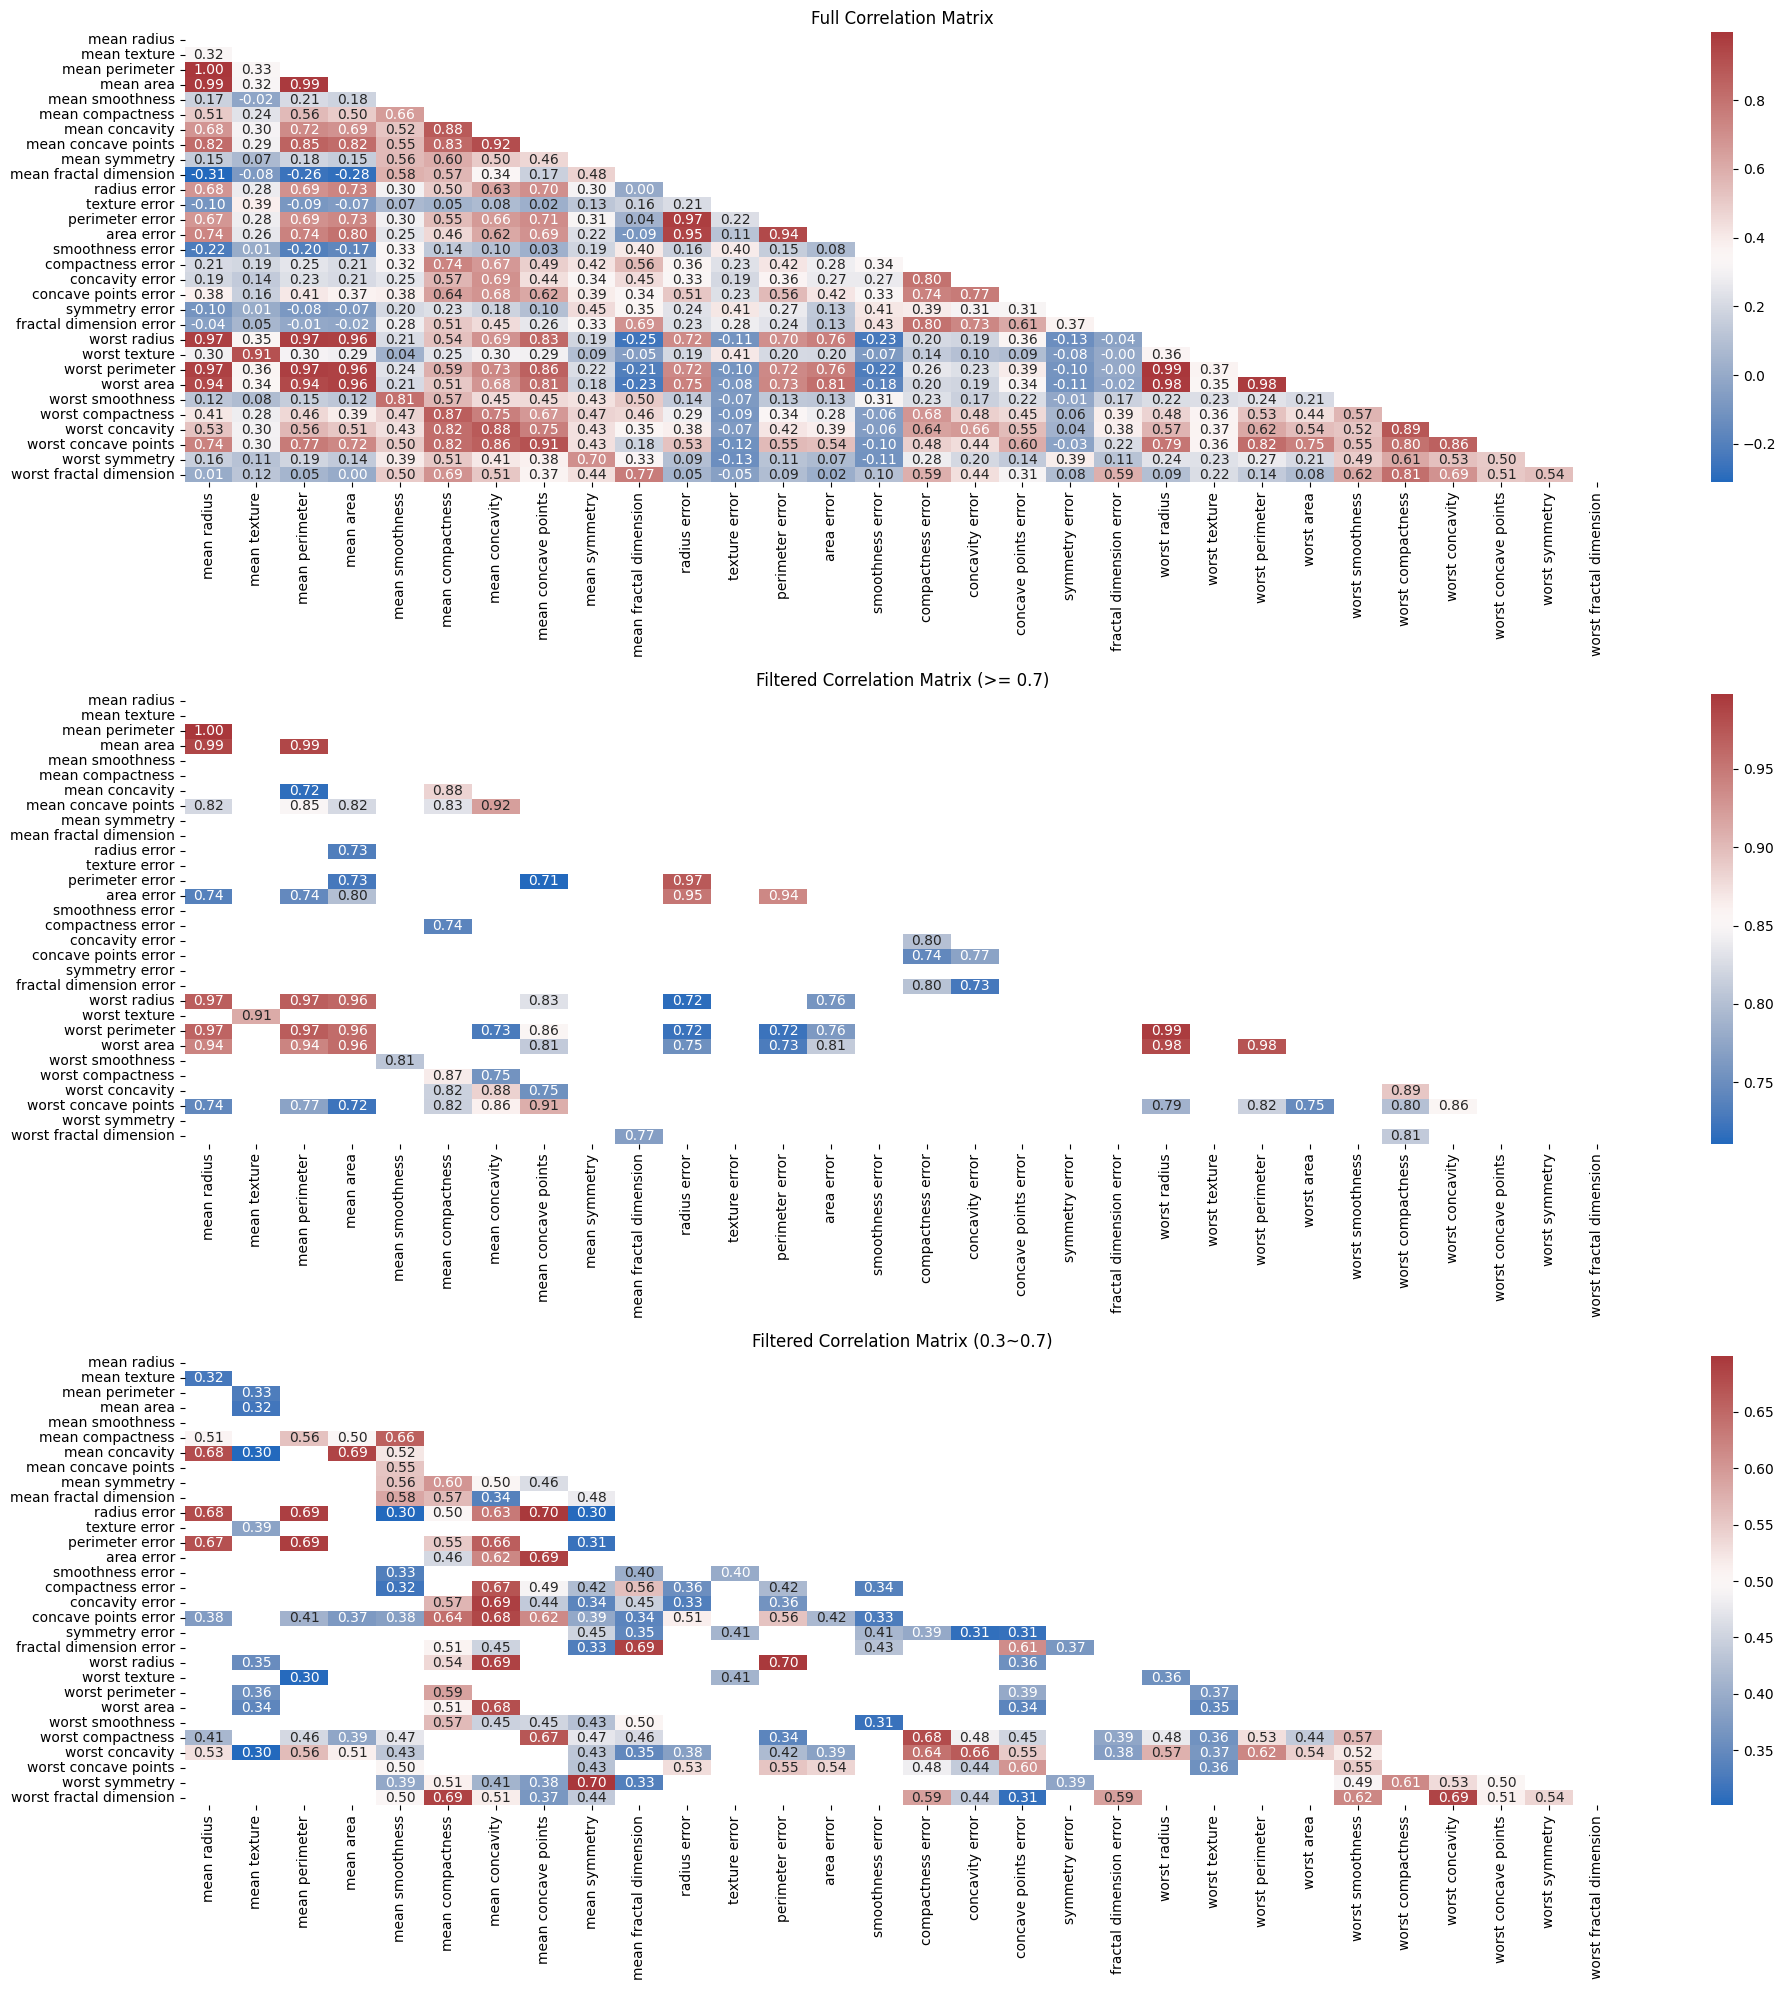

In [9]:
from sklearn.datasets import load_breast_cancer

# 加载数据集
data = load_breast_cancer(as_frame = True)

# 获取特征和目标
X = data.data  # 特征
y = data.target  # 目标
labels = X.columns
target = pd.DataFrame(data.target.values, columns = ['target'])

# Plot the correlation matrix with two decimal places
fig, axes = plt.subplots(3, 1, figsize=(20, 20))

# Full correlation matrix
R = X.corr()
mask = np.triu(np.ones_like(R, dtype=bool))  # diagonal mask
seaborn.heatmap(R, annot=True, mask=mask, cmap='vlag', fmt=".2f", ax=axes[0])  # Use fmt=".2f" for two decimal places
axes[0].set_title('Full Correlation Matrix')

# Filtered correlation matrix
R_filtered = R[(R >= 0.7) & (R < 1)]  # Filter correlation matrix for values greater than or equal to 0.7
mask_filtered = np.triu(np.ones_like(R_filtered, dtype=bool))
seaborn.heatmap(R_filtered, annot=True, mask=mask_filtered, cmap='vlag', fmt=".2f", ax=axes[1])  # Use fmt=".2f" for two decimal places
axes[1].set_title('Filtered Correlation Matrix (>= 0.7)')

# Filtered correlation matrix
R_filtered_mid = R[(R >= 0.3) & (R < 0.7)]  
mask_filtered_mid = np.triu(np.ones_like(R_filtered_mid, dtype=bool))
seaborn.heatmap(R_filtered_mid, annot=True, mask=mask_filtered_mid, cmap='vlag', fmt=".2f", ax=axes[2])  # Use fmt=".2f" for two decimal places
axes[2].set_title('Filtered Correlation Matrix (0.3~0.7)')
plt.tight_layout()
plt.show()


**<font color=skyblue>結果的觀察與討論：</font>**
- 因變數過多，在此僅列出一些變數關係舉例
- 第一張圖呈現所有變數之間的相關係數，並控制四捨五入至小數點第二位
- 第二張圖呈現高度相關的變數
    - 變數mean radius與變數mean perimeter/變數mean area/變數worst radius/變數worst perimeter和變數worst area的相關係數都很高，推測具有線性關係
- 第三張圖呈現中度相關的變數
    - 變數mean radius與變數mean concavity/變數radius  error和變數perimeter  error相關係數具有中度相關的性質
- 如需做資料縮減，建議從此類高度相關的變數進行合併新變數或者刪除其中某個變數下手
    

**<font color=skyblue>第 2 題：</font>**
- Claim:了解變數是否需要標準化
    - 繪製一張含每個化學成分（變數）的盒鬚圖（Boxplot），觀察每個變數的 scaling，作為是否標準化的參考。

In [10]:
print(data['target_names'])

['malignant' 'benign']


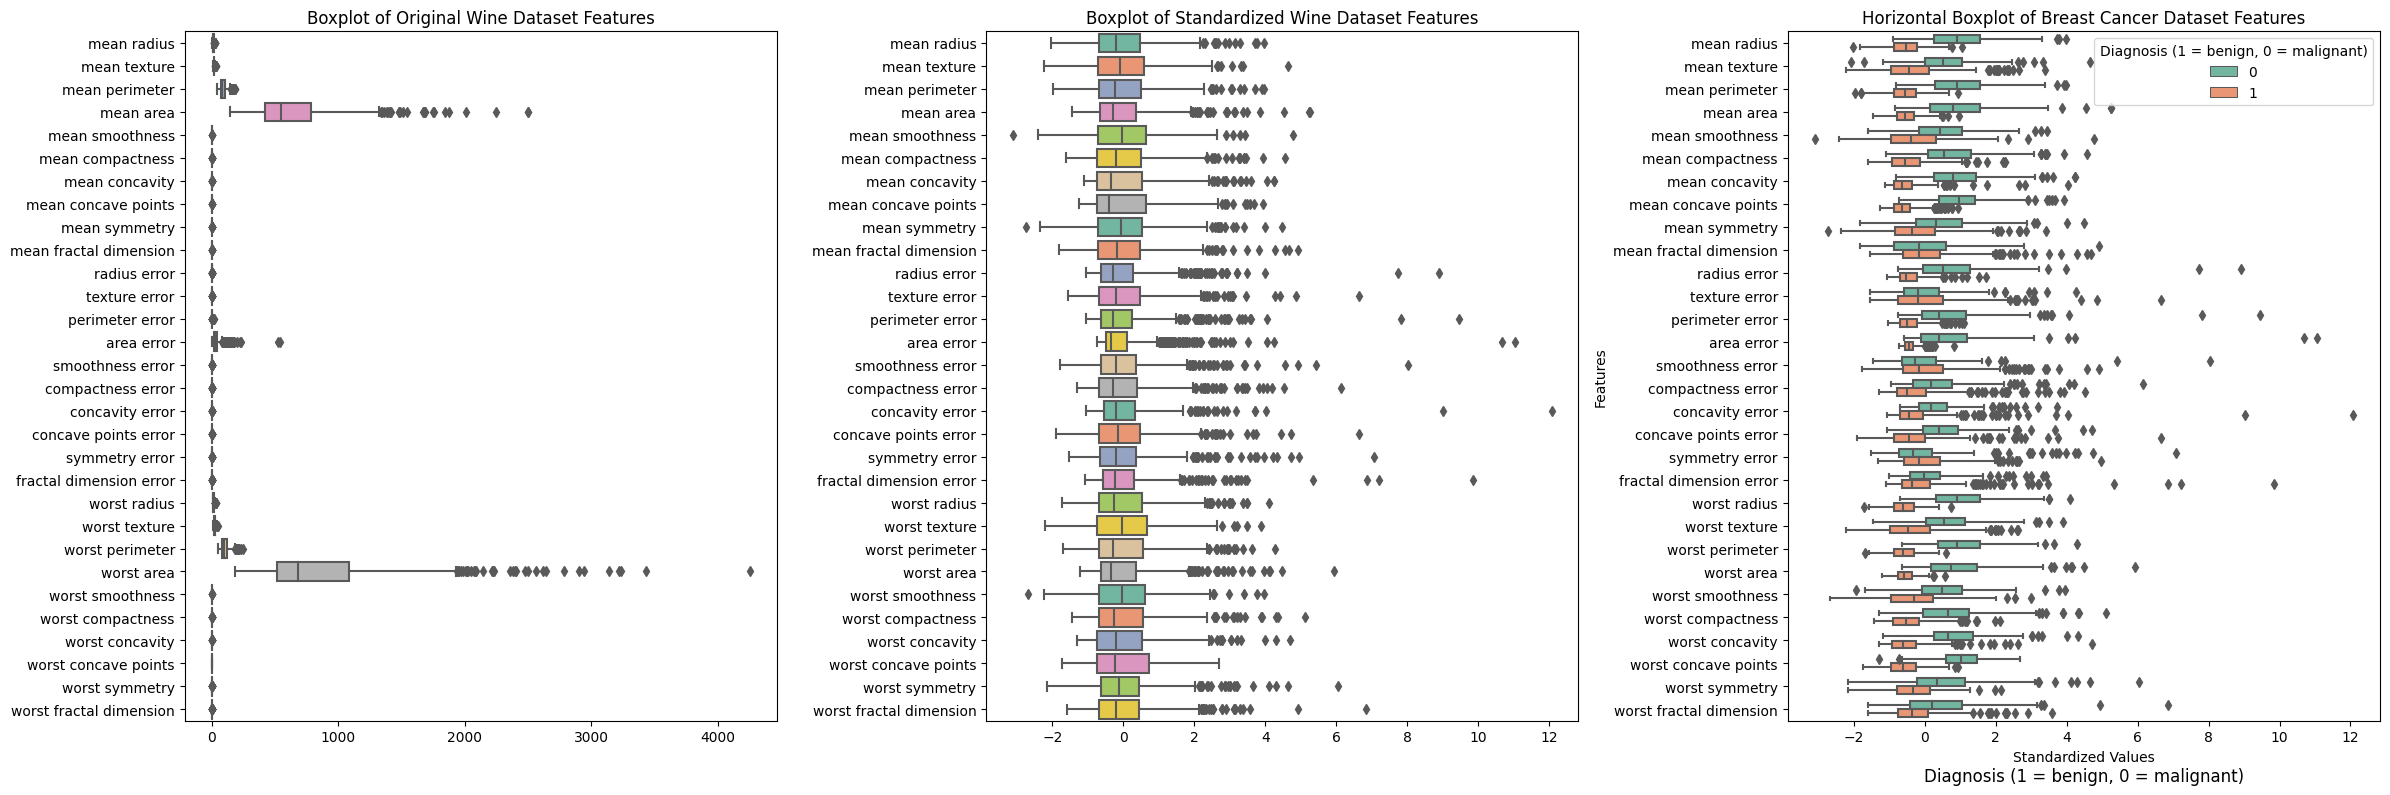

In [11]:
# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 转换为DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=labels)

# 合并特征和目标
data_scaled = pd.concat([X_scaled_df, target], axis=1)

# 重塑数据以进行绘制
data_melted = data_scaled.melt(id_vars='target', var_name='Feature', value_name='Value')

# 创建画布
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# 绘制原始数据的盒须图
sns.boxplot(data=X, orient="h", palette="Set2", ax=axes[0])
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels)
axes[0].set_title('Boxplot of Original Wine Dataset Features')

# 绘制标准化数据的盒须图
sns.boxplot(data=X_scaled, orient="h", palette="Set2", ax=axes[1])
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels)
axes[1].set_title('Boxplot of Standardized Wine Dataset Features')

# 绘制水平盒须图
ax = sns.boxplot(data=data_melted, y='Feature', x='Value', hue='target', palette='Set2', orient='h', width=0.7, ax=axes[2])
ax.set_title('Horizontal Boxplot of Breast Cancer Dataset Features')
ax.set_xlabel('Standardized Values')
ax.set_ylabel('Features')
ax.legend(title='Diagnosis (1 = benign, 0 = malignant)', loc='upper right')
ax.annotate('Diagnosis (1 = benign, 0 = malignant)', xy=(0.5, -0.08), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

**<font color=skyblue>結果的觀察與討論：</font>**
- 左圖呈現未經標準化的盒鬚圖
    - 可以看出變數mean area/變數worst area明顯與其他變數有很大的單位差異
- 中圖呈現經標準化的盒鬚圖，但會發現有很多離群值，因此將資料的良性與惡性分開繪製(使用print(data['target_names'])了解0是惡性/1是良性)
    - 可以變數變數之間沒有明顯與其他變數有很大的單位差異
- 右圖呈現經標準化及分為良性與惡性的盒鬚圖
    - 可以發現不論良性與惡性的極端值都還是有許多，但相較中圖來的好一些，可以依後續目標不同而對資料有不同的處理方式
- 後續將主要使用標準化變數(中圖)，避免後續模型因變數的單位不同，而造成模型權重偏向數值較大的變數，或者模型係數大小差異極大的問題。


**<font color=skyblue>第 3 題：</font>**
- Claim:進行主成分分析，繪製特徵值由大而小的分布與 scree plot。
    - 繪製未標準化與標準化後變數的Scree plot與Pareto plot

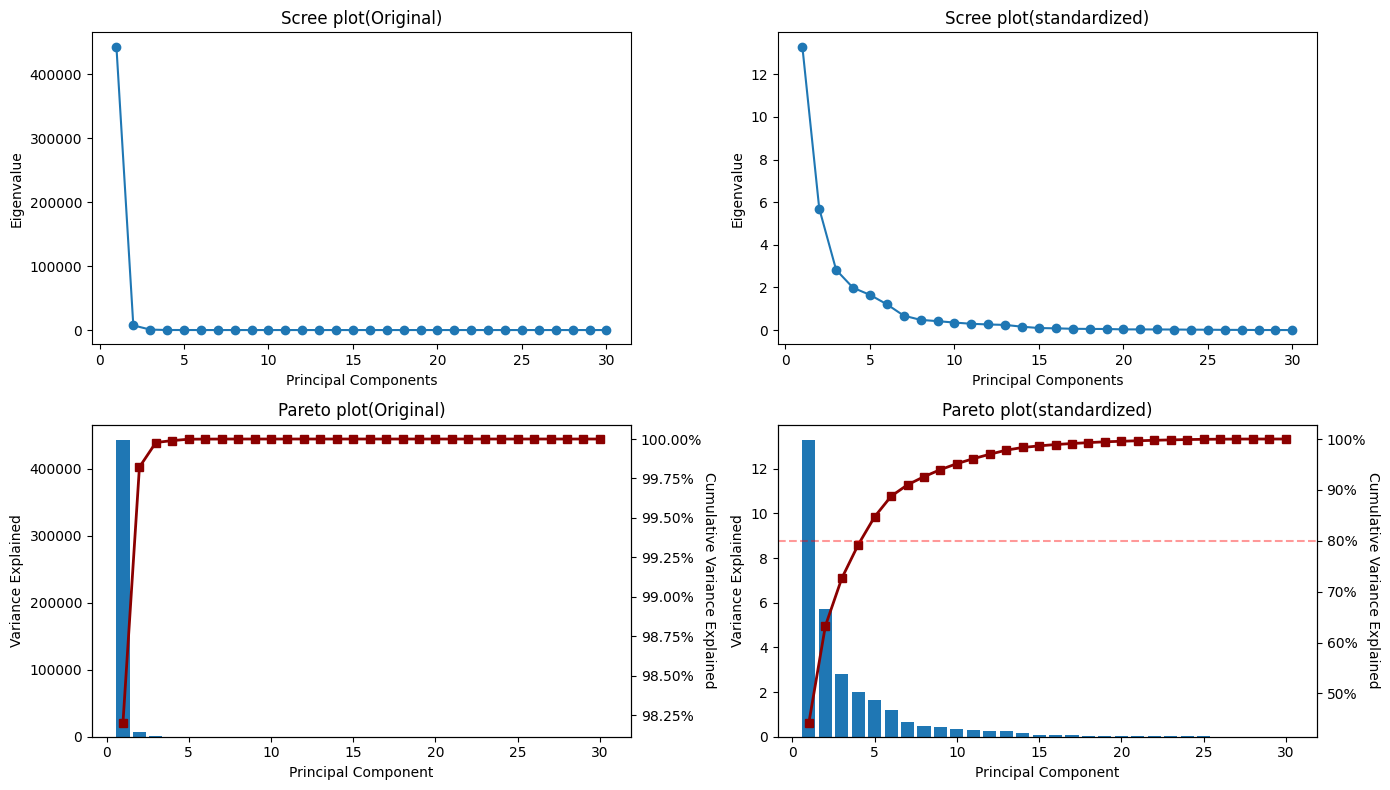

In [12]:
# Calculate covariance matrix and perform eigen decomposition
Sx = np.cov(X.T, bias=False)
w, v = eig(Sx)
idx = np.argsort(w)[::-1]
eigvals = w[idx]
eigvecs = v[:, idx]
Sigma_x = eigvecs @ np.diag(eigvals) @ eigvecs.T

# Plot original data scree plot and Pareto plot
plt.figure(figsize=(14, 8))
plt.subplot(221)
x = np.arange(1, 1 + len(eigvals))
plt.plot(x, eigvals, marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.title('Scree plot(Original)')

plt.subplot(223)
ax = plt.gca()
ax.bar(x, eigvals)
ax2 = ax.twinx()
ax2.plot(x, eigvals.cumsum() / eigvals.sum() * 100, marker='s', color='darkred', lw=2)
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax2.set_ylabel('Cumulative Variance Explained', rotation=270, labelpad=10)
plt.title('Pareto plot(Original)')

# Calculate covariance matrix and perform eigen decomposition for standardized data
Sx2 = np.cov(X_scaled.T, bias=False)
w2, v2 = eig(Sx2)
idx2 = np.argsort(w2)[::-1]
eigvals2 = w2[idx2]
eigvecs2 = v2[:, idx2]
Sigma_x2 = eigvecs2 @ np.diag(eigvals2) @ eigvecs2.T

# Plot standardized data scree plot and Pareto plot
plt.subplot(222)
x2 = np.arange(1, 1 + len(eigvals2))
plt.plot(x2, eigvals2, marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.title('Scree plot(standardized)')

plt.subplot(224)
ax = plt.gca()
ax.bar(x2, eigvals2)
ax2 = ax.twinx()
ax2.plot(x2, eigvals2.cumsum() / eigvals2.sum() * 100, marker='s', color='darkred', lw=2)
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax2.set_ylabel('Cumulative Variance Explained', rotation=270, labelpad=10)
plt.title('Pareto plot(standardized)')
plt.axhline(y=80, color='r', linestyle='--', alpha = 0.4)  # Draw horizontal line at y=4
plt.tight_layout()
plt.show()

**<font color=skyblue>結果的觀察與討論：</font>**
- 左方為未標準化的Scree plot與Pareto plot
    - 可以看出第一個特徵值極大(超過40萬)，應該是因為變數mean area/變數worst area明顯與其他變數有很大的單位差異所導致
    - 如果採用此結果，因Scree plot結構轉變點在第2個主成分，我會使用兩個變數進行後續研究。
- 右方為標準化的Scree plot與Pareto plot
    - 可以看出特徵值最大不超過4，所有的特徵值數值差異沒未標準化數據的大
    - 如果採用此結果，Scree plot並沒有發生明顯的結構轉變點，因此我會以Pareto plot在第五個變數解釋近80%的樣本的觀察，後續研究使用五個變數。
- 建議使用標準化變數的結果進行後續分析。
    

**<font color=skyblue>第 4 題：</font>**
- Claim:利用主成分分析取得前兩項成分，並繪製其散布圖。是否可以從散布圖中看出三個群組？
    - 繪製未標準化數據與標準化數據的散布圖

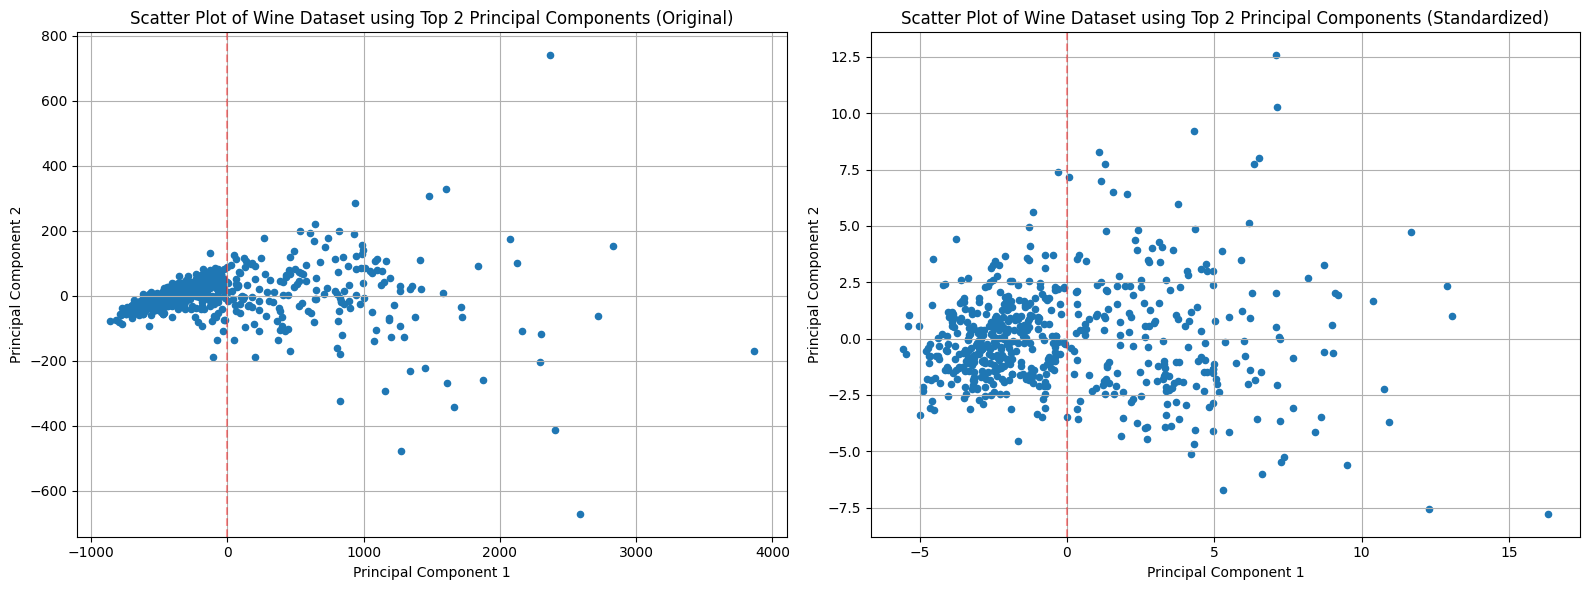

In [13]:
# Fit PCA and transform the data to the new space
PCA_result = PCA(n_components=2).fit_transform(X)

# Plot the scatter plot
plt.figure(figsize=(16, 6))

# Plot for the original data
plt.subplot(1, 2, 1)
plt.scatter(PCA_result[:, 0], PCA_result[:, 1], s=20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of Wine Dataset using Top 2 Principal Components (Original)')
plt.grid(True)
plt.axvline(x=0, color='r', linestyle='--', alpha = 0.4)  # Draw vertical line at x=0

# Fit PCA and transform the standardized data to the new space
PCA_result2 = PCA(n_components=2).fit_transform(X_scaled)

# Plot for the standardized data
plt.subplot(1, 2, 2)
plt.scatter(PCA_result2[:, 0], PCA_result2[:, 1], s=20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of Wine Dataset using Top 2 Principal Components (Standardized)')
plt.grid(True)
plt.axvline(x=0, color='r', linestyle='--', alpha = 0.4)  # Draw vertical line at x=0
plt.tight_layout()
plt.show()

**<font color=skyblue>結果的觀察與討論：</font>**
- 左方為未標準化的散布圖(紅線部分為猜測的群組的分界部分)
- 右方為標準化的散布圖(紅線部分為猜測的群組的分界部分)
- 如果使用兩個主成分的散佈圖，無論有無標準化，均無法觀察兩種群組的分布情況，猜測因變數不足以有效分辨差異

**<font color=skyblue>第 5 題：</font>**
- Claim:呈上題，為散佈圖標示上群組的分別
    - 繪製未標準化數據與標準化數據的散布圖，並塗上群組顏色

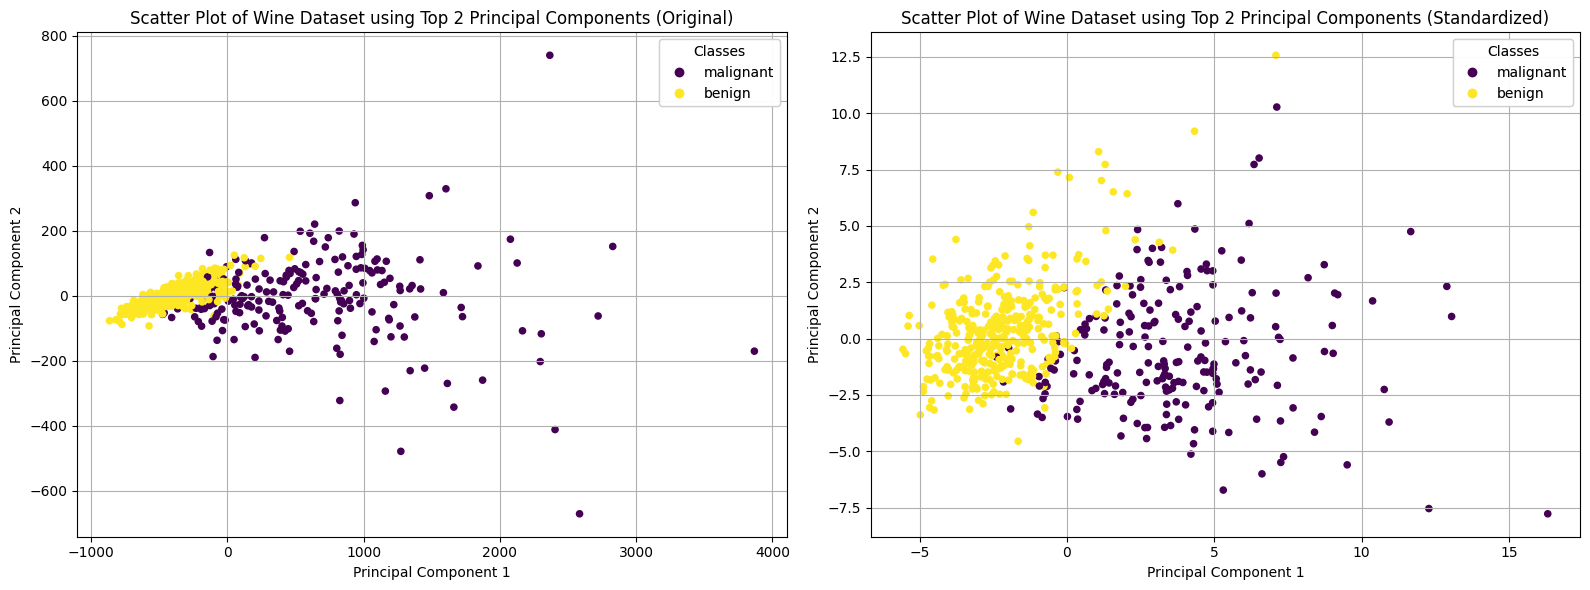

In [14]:
# Fit PCA and transform the data to the new space
PCA_result = PCA(n_components=2).fit_transform(X)

# Plot the scatter plot
plt.figure(figsize=(16, 6))

# Plot for the original data
plt.subplot(1, 2, 1)
scatter = plt.scatter(PCA_result[:, 0], PCA_result[:, 1], s=20, c=y, label='Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of Wine Dataset using Top 2 Principal Components (Original)')
plt.grid(True)
legend1 = plt.legend(handles=scatter.legend_elements()[0], labels=['malignant','benign'], title="Classes", loc='upper right')
plt.gca().add_artist(legend1)

# Fit PCA and transform the standardized data to the new space
PCA_result2 = PCA(n_components=2).fit_transform(X_scaled)

# Plot for the standardized data
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(PCA_result2[:, 0], PCA_result2[:, 1], s=20, c=y, label='Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of Wine Dataset using Top 2 Principal Components (Standardized)')
plt.grid(True)
legend2 = plt.legend(handles=scatter2.legend_elements()[0], labels=['malignant','benign'], title="Classes", loc='upper right')
plt.gca().add_artist(legend2)
plt.tight_layout()
plt.show()

**<font color=skyblue>結果的觀察與討論：</font>**
- 左方為未標準化的散布圖
    -可以發現雖然良性集中在左邊，但還是有許多惡性混雜在一起
- 右方為標準化的散布圖
    -可以發現良性集中在左邊，並且相比未標準化的散布圖，惡性混雜在一起的較少
- 在兩個主成分的情況下，標準化數據在此樣本中比未標準化數據，更有效地分辨出兩個群組的差別。
- 如需在分清楚一點，建議使用多一點的變數
- 相比於原本的30個變數，使用PCA的方法可以有效把變數數量降低，並大致分出兩個群組。

**<font color=skyblue>第 6 題：</font>**
- Claim:利用主成分分析取得前三項成分，並繪製其散布圖。是否可以從散布圖中看出兩個群組？
    - 繪製未標準化數據與標準化數據的散布圖

In [15]:
# Fit PCA and transform the data to the new space
PCA_result = PCA(n_components=3).fit_transform(X)

# Create a DataFrame for Plotly Express
df = pd.DataFrame(PCA_result, columns=['PC1', 'PC2', 'PC3'])
df['Class'] = y

# Create an interactive 3D scatter plot using Plotly Express
fig = px.scatter_3d(df, x='PC1', y='PC2', z='PC3', color='Class', title='3D Scatter Plot of Original Wine Dataset using Top 3 Principal Components',
                    size_max=5)
fig.update_traces(marker_size = 4)
fig.show()
# Fit PCA and transform the data to the new space
PCA_result2 = PCA(n_components=3).fit_transform(X_scaled)

# Create a DataFrame for Plotly Express
df2 = pd.DataFrame(PCA_result2, columns=['PC1', 'PC2', 'PC3'])
df2['Class'] = y

# Create an interactive 3D scatter plot using Plotly Express
fig = px.scatter_3d(df2, x='PC1', y='PC2', z='PC3', color='Class', title='3D Scatter Plot of standardize Wine Dataset using Top 3 Principal Components',
                    size_max=5)
fig.update_traces(marker_size = 4)
fig.show()

**<font color=skyblue>結果的觀察與討論：</font>**
- 上方為未標準化的立體散布圖
    -從不同角度看會發現以pc1與pc2為底面，群組1與群組2在pc3較低的數值部分混雜在一起，導致無法有效分別出兩種群組
- 下方為標準化的立體散布圖
    -可以發現前三項主成分已經可以很有效地分別兩個群組
- 經過立體散布圖會發現
    - 使用未標準化的資料，三個主成分也未能有效分辨出群組的界線
    - 使用標準化的資料，三個主成分即可有效分辨出群組的界線
    - 因此選擇主成分方法的話，使用標準化的資料及兩個主成分會是這個數據集的最佳解

**<font color=skyblue>第 7 題：</font>**
- Claim:了解新變數$Z_1$與$Z_2$的組成方式
    - 對於對稱矩陣$A$來說(因A矩陣為相關係數矩陣，必為對稱矩陣)，必可寫為光譜分解式$A=\lambda_1v_1v_1^*+\cdots+\lambda_mv_mv_m^*$，其中$v_i$為第$i$個特徵值的特徵向量，$\lambda_i$從大排到小，$i=1,2,...,13$
    - 因為$Z_1$=$\lambda_1v_1v_1^*$，所以影響$Z_1$值最多的即為$v_1$中最大值的變數，$Z_2$也同理

In [16]:
pca = PCA(n_components=2).fit(X)
eigvecs = pca.components_.T

# Get the indices of the top three highest coefficients for PC1
top_three_indices_pc1 = np.argsort(abs(eigvecs[:, 0]))[::-1][:3]
# Get the variable names corresponding to the top three indices for PC1
top_three_variables_pc1 = labels[top_three_indices_pc1]
# Get the values of the top three coefficients for PC1
top_three_coefficients_pc1 = eigvecs[top_three_indices_pc1, 0]

# Get the indices of the top three highest coefficients for PC2
top_three_indices_pc2 = np.argsort(abs(eigvecs[:, 1]))[::-1][:3]
# Get the variable names corresponding to the top three indices for PC2
top_three_variables_pc2 = labels[top_three_indices_pc2]
# Get the values of the top three coefficients for PC2
top_three_coefficients_pc2 = eigvecs[top_three_indices_pc2, 1]

# Combine variable names and coefficients into a list of tuples for PC1
top_three_info_pc1 = list(zip(top_three_variables_pc1, top_three_coefficients_pc1))

# Combine variable names and coefficients into a list of tuples for PC2
top_three_info_pc2 = list(zip(top_three_variables_pc2, top_three_coefficients_pc2))
print("原始數據")
print("Variable names and their corresponding coefficients for PC1(Z1):")
for variable, coefficient in top_three_info_pc1:
    print(f"{variable}: {coefficient}")

print("\nVariable names and their corresponding coefficients for PC2(Z2):")
for variable, coefficient in top_three_info_pc2:
    print(f"{variable}: {coefficient}")

print('-----------------------------------------------------------------------')
pca = PCA(n_components=2).fit(X_scaled)
eigvecs = pca.components_.T

# Get the indices of the top three highest coefficients for PC1
top_three_indices_pc1 = np.argsort(abs(eigvecs[:, 0]))[::-1][:3]
# Get the variable names corresponding to the top three indices for PC1
top_three_variables_pc1 = labels[top_three_indices_pc1]
# Get the values of the top three coefficients for PC1
top_three_coefficients_pc1 = eigvecs[top_three_indices_pc1, 0]

# Get the indices of the top three highest coefficients for PC2
top_three_indices_pc2 = np.argsort(abs(eigvecs[:, 1]))[::-1][:3]
# Get the variable names corresponding to the top three indices for PC2
top_three_variables_pc2 = labels[top_three_indices_pc2]
# Get the values of the top three coefficients for PC2
top_three_coefficients_pc2 = eigvecs[top_three_indices_pc2, 1]

# Combine variable names and coefficients into a list of tuples for PC1
top_three_info_pc1 = list(zip(top_three_variables_pc1, top_three_coefficients_pc1))

# Combine variable names and coefficients into a list of tuples for PC2
top_three_info_pc2 = list(zip(top_three_variables_pc2, top_three_coefficients_pc2))
print("標準化數據")
print("Variable names and their corresponding coefficients for PC1(Z1):")
for variable, coefficient in top_three_info_pc1:
    print(f"{variable}: {coefficient}")

print("\nVariable names and their corresponding coefficients for PC2(Z2):")
for variable, coefficient in top_three_info_pc2:
    print(f"{variable}: {coefficient}")


原始數據
Variable names and their corresponding coefficients for PC1(Z1):
worst area: 0.8520633917981476
mean area: 0.5168264687224566
area error: 0.05572716691107055

Variable names and their corresponding coefficients for PC2(Z2):
mean area: 0.8518237204834209
worst area: -0.5197423583172223
mean perimeter: 0.06274808274893222
-----------------------------------------------------------------------
標準化數據
Variable names and their corresponding coefficients for PC1(Z1):
mean concave points: 0.2608537583857395
mean concavity: 0.258400481248769
worst concave points: 0.25088597121799877

Variable names and their corresponding coefficients for PC2(Z2):
mean fractal dimension: 0.3665754713784434
fractal dimension error: 0.28009202661150384
worst fractal dimension: 0.2753394685801682


**<font color=skyblue>結果的觀察與討論：</font>**
- 上方為未標準化的組成係數
    - 對於$Z_1$來說，worst area變數影響極大
    - 對於$Z_2$來說，mean area變數影響極大
- 下方為標準化的組成係數
    - 對於$Z_1$來說，mean concave points/mean concavity/worst concave points變數均影響比其他變數多，且影響滿接近的，並且變數之間成高度相關，且都為凹點的相關變數，建議可以組成新變數可命名為凹點指標做後續研究使用
    - 對於$Z_2$來說，mean fractal dimension/fractal dimension error/worst fractal dimension變數均影響比其他變數多，且影響滿接近的，並且變數之間成中度與高度相關，且都為分形維數的相關變數，建議可以組成新變數可命名為分形維數指標做後續研究使用
- 經過所有的分析探討後，資料進行標準化，並且適合彙整新指標變數做使用
